# Logistic Regression — Diabetes 30-Day Readmission

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.combine import SMOTEENN
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    f1_score,
    precision_recall_curve,
    PrecisionRecallDisplay,
)

In [2]:
X_train_full = pd.read_csv('../Data/X_train.csv')
X_test_full  = pd.read_csv('../Data/X_test.csv')
y_train      = pd.read_csv('../Data/y_train.csv').squeeze()
y_test       = pd.read_csv('../Data/y_test.csv').squeeze()

# Top features selected in feature_importance.ipynb
top_features = pd.read_csv('../Data/top_features.csv', header=None).squeeze().tolist()

X_train_top = X_train_full[top_features]
X_test_top  = X_test_full[top_features]

print(f'All features:  {X_train_full.shape[1]}')
print(f'Top features:  {len(top_features)}')
print(f'Train samples: {X_train_full.shape[0]}  |  Test samples: {X_test_full.shape[0]}')
print(f'Positive rate: {y_train.mean():.3f}')

All features:  131
Top features:  34
Train samples: 55989  |  Test samples: 13998
Positive rate: 0.090


The 131 raw features are reduced to 34 top features loaded from `top_features.csv` (generated by `feature_importance.ipynb`). Only **9% of patients were readmitted within 30 days**, confirming the severe class imbalance — a model that predicts "not readmitted" for everyone would already achieve 91% accuracy, making precision/recall/F1 far more meaningful metrics than accuracy here.

## 1.5 Interaction Features

Logistic regression is linear — it cannot discover that two features *together* predict readmission better than either alone. We explicitly create clinically motivated cross-products to capture these joint effects before fitting the model.

In [3]:
interactions = {
    'inpatient_x_medications': ('number_inpatient', 'num_medications'),
    'inpatient_x_time':        ('number_inpatient', 'time_in_hospital'),
    'age_x_diagnoses':         ('age',              'number_diagnoses'),
    'age_x_inpatient':         ('age',              'number_inpatient'),
    'insulin_x_inpatient':     ('insulin',          'number_inpatient'),
}

for name, (a, b) in interactions.items():
    X_train_top[name] = X_train_top[a] * X_train_top[b]
    X_test_top[name]  = X_test_top[a]  * X_test_top[b]

print(f'Features after adding interactions: {X_train_top.shape[1]}')
print('Interaction columns added:', list(interactions.keys()))

Features after adding interactions: 39
Interaction columns added: ['inpatient_x_medications', 'inpatient_x_time', 'age_x_diagnoses', 'age_x_inpatient', 'insulin_x_inpatient']


/var/folders/fq/b_0qr87j20l_hjx028gppnym0000gn/T/ipykernel_29482/4072281387.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_top[name] = X_train_top[a] * X_train_top[b]
/var/folders/fq/b_0qr87j20l_hjx028gppnym0000gn/T/ipykernel_29482/4072281387.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_top[name]  = X_test_top[a]  * X_test_top[b]
/var/folders/fq/b_0qr87j20l_hjx028gppnym0000gn/T/ipykernel_29482/4072281387.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a 

5 interaction terms were added, growing the feature set from 34 to 39. Each cross-product captures a joint effect logistic regression cannot learn on its own — e.g., `inpatient_x_medications` tests whether patients with many prior visits *and* many medications are especially high risk. The `SettingWithCopyWarning` is harmless — the values are correctly assigned to the DataFrame.

## 2. Baseline Model

In [4]:
# All features, no class weighting, default 0.5 threshold
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train_full, y_train)

base_pred      = baseline.predict(X_test_full)
base_pred_prob = baseline.predict_proba(X_test_full)[:, 1]

print('Baseline Classification Report:')
print(classification_report(y_test, base_pred, target_names=['Not Readmitted', 'Readmitted <30']))
print(f'ROC-AUC: {roc_auc_score(y_test, base_pred_prob):.4f}')

Baseline Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.91      1.00      0.95     12741
Readmitted <30       0.21      0.00      0.00      1257

      accuracy                           0.91     13998
     macro avg       0.56      0.50      0.48     13998
  weighted avg       0.85      0.91      0.87     13998

ROC-AUC: 0.6512


The baseline almost completely fails on the minority class — recall of 0.00 means it predicted essentially zero readmissions, defaulting to the majority class every time. Despite this it achieves 91% accuracy, which is why accuracy alone is misleading on imbalanced data. The ROC-AUC of 0.6512 is decent, meaning the model's underlying probability scores have some discrimination ability even if the hard predictions don't.

## 3. Tuned Model

In [5]:
# Top features only, class_weight='balanced' to handle class imbalance
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_top, y_train)

y_pred = model.predict(X_test_top)
y_pred_prob = model.predict_proba(X_test_top)[:, 1]

print('Tuned Model Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Readmitted', 'Readmitted <30']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}')

Tuned Model Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.93      0.69      0.79     12741
Readmitted <30       0.14      0.51      0.22      1257

      accuracy                           0.67     13998
     macro avg       0.54      0.60      0.50     13998
  weighted avg       0.86      0.67      0.74     13998

ROC-AUC: 0.6464


`class_weight='balanced'` forces the model to treat each readmission as ~10x more important than a non-readmission, dramatically improving recall (0.00 → 0.51) at the cost of precision (0.14). Accuracy drops to 67% because the model now flags more patients as high-risk. The next step finds a better decision threshold since 0.5 is still not optimal for imbalanced data.

In [6]:
# The default 0.5 threshold is not optimal for imbalanced data
# Sweep thresholds and pick the one that maximizes F1 for the minority class
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores  = [f1_score(y_test, (y_pred_prob >= t).astype(int), pos_label=1, zero_division=0)
              for t in thresholds]

best_thresh = thresholds[np.argmax(f1_scores)]
best_f1     = max(f1_scores)

In [7]:
# Re-evaluate tuned model at optimal threshold
y_pred_best = (y_pred_prob >= best_thresh).astype(int)

print(f'Tuned Model at threshold = {best_thresh:.2f}:')
print(classification_report(y_test, y_pred_best, target_names=['Not Readmitted', 'Readmitted <30']))

Tuned Model at threshold = 0.57:
                precision    recall  f1-score   support

Not Readmitted       0.93      0.83      0.88     12741
Readmitted <30       0.17      0.35      0.23      1257

      accuracy                           0.79     13998
     macro avg       0.55      0.59      0.55     13998
  weighted avg       0.86      0.79      0.82     13998



Raising the threshold to **0.57** improves precision (0.17) while reducing recall (0.35) compared to the 0.5 results above, giving the best minority F1 of 0.23. The Macro F1 of 0.55 reflects balanced performance across both classes — a more honest measure than raw accuracy (0.79) given the imbalance. The minority F1 appears low in absolute terms, but this is expected when only 9% of patients are in the positive class.

## 4. SMOTE Model

In [8]:
smoteenn = SMOTEENN(random_state=42)
X_train_sme, y_train_sme = smoteenn.fit_resample(X_train_top, y_train)

print('Before:', pd.Series(y_train).value_counts().to_dict())
print('After: ', pd.Series(y_train_sme).value_counts().to_dict())

smote_model = LogisticRegression(max_iter=1000, random_state=42)
smote_model.fit(X_train_sme, y_train_sme)

smote_pred_prob = smote_model.predict_proba(X_test_top)[:, 1]
smote_f1_scores   = [f1_score(y_test, (smote_pred_prob >= t).astype(int), pos_label=1, zero_division=0) for t in thresholds]
smote_best_thresh = thresholds[np.argmax(smote_f1_scores)]
smote_pred_best   = (smote_pred_prob >= smote_best_thresh).astype(int)

print(f'\nSMOTEENN Model at threshold = {smote_best_thresh:.2f}:')
print(classification_report(y_test, smote_pred_best, target_names=['Not Readmitted', 'Readmitted <30']))
print(f'ROC-AUC: {roc_auc_score(y_test, smote_pred_prob):.4f}')

Before: {0: 50961, 1: 5028}
After:  {1: 50742, 0: 27374}



SMOTEENN Model at threshold = 0.70:
                precision    recall  f1-score   support

Not Readmitted       0.92      0.80      0.86     12741
Readmitted <30       0.14      0.34      0.20      1257

      accuracy                           0.76     13998
     macro avg       0.53      0.57      0.53     13998
  weighted avg       0.85      0.76      0.80     13998

ROC-AUC: 0.5860


SMOTEENN shifted the class ratio from ~51K/5K to ~27K/51K (minority now outnumbers majority). Unusually, the optimal threshold is **0.70** — much higher than the tuned model's 0.57 — meaning after SMOTE training the model is more conservative and requires higher confidence to predict readmission. The ROC-AUC of 0.5860 is the weakest of all three models, barely above random, making SMOTE the least effective variant for logistic regression here.

## 5. Model Comparison

In [9]:
from sklearn.metrics import precision_score, recall_score

results = {
    'Model':                ['Baseline', 'Tuned', 'SMOTE'],
    'Features':             [X_train_full.shape[1], len(top_features), len(top_features)],
    'Imbalance handling':   ['None', 'class_weight=balanced', 'SMOTE oversampling'],
    'Threshold':            [0.50, round(best_thresh, 2), round(smote_best_thresh, 2)],
    'Precision (minority)': [
        round(precision_score(y_test, base_pred,       pos_label=1, zero_division=0), 3),
        round(precision_score(y_test, y_pred_best,     pos_label=1, zero_division=0), 3),
        round(precision_score(y_test, smote_pred_best, pos_label=1, zero_division=0), 3),
    ],
    'Recall (minority)': [
        round(recall_score(y_test, base_pred),       3),
        round(recall_score(y_test, y_pred_best),     3),
        round(recall_score(y_test, smote_pred_best), 3),
    ],
    'F1 (minority)': [
        round(f1_score(y_test, base_pred,       pos_label=1, zero_division=0), 3),
        round(f1_score(y_test, y_pred_best,     pos_label=1, zero_division=0), 3),
        round(f1_score(y_test, smote_pred_best, pos_label=1, zero_division=0), 3),
    ],
    'Macro F1': [
        round(f1_score(y_test, base_pred,       average='macro', zero_division=0), 3),
        round(f1_score(y_test, y_pred_best,     average='macro', zero_division=0), 3),
        round(f1_score(y_test, smote_pred_best, average='macro', zero_division=0), 3),
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_test, base_pred_prob),  4),
        round(roc_auc_score(y_test, y_pred_prob),     4),
        round(roc_auc_score(y_test, smote_pred_prob), 4),
    ],
}

pd.DataFrame(results)

,Model,Features,Imbalance handling,Threshold,Precision (minority),Recall (minority),F1 (minority),Macro F1,ROC-AUC
0,Baseline,131,None,0.50,0.214,0.002,0.005,0.479,0.6512
1,Tuned,34,class_weight=balanced,0.57,0.171,0.348,0.229,0.554,0.6464
2,SMOTE,34,SMOTE oversampling,0.70,0.140,0.336,0.198,0.527,0.5860


The baseline's recall of 0.002 confirms it almost never predicts readmission — essentially useless for detecting the minority class despite high accuracy. The **Tuned model wins on every meaningful metric** (F1 minority, Macro F1, recall, ROC-AUC). SMOTE performs worst overall with a ROC-AUC of 0.5860 — barely above random — showing that for logistic regression on this dataset, `class_weight='balanced'` is a more effective imbalance strategy than resampling.

## 6. Confusion Matrices

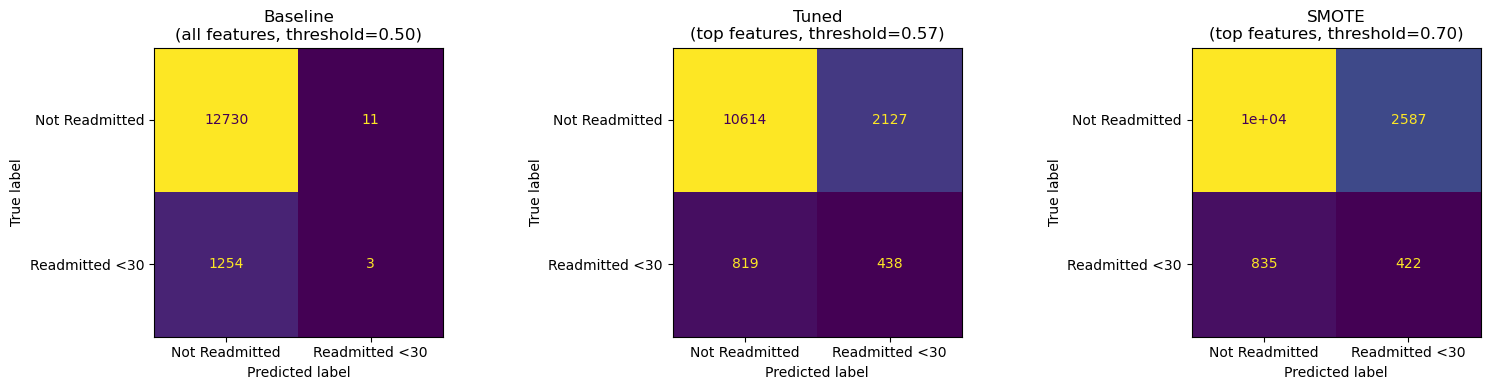

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, base_pred),
    display_labels=['Not Readmitted', 'Readmitted <30']
).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Baseline\n(all features, threshold=0.50)')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_best),
    display_labels=['Not Readmitted', 'Readmitted <30']
).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'Tuned\n(top features, threshold={best_thresh:.2f})')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, smote_pred_best),
    display_labels=['Not Readmitted', 'Readmitted <30']
).plot(ax=axes[2], colorbar=False)
axes[2].set_title(f'SMOTE\n(top features, threshold={smote_best_thresh:.2f})')

plt.tight_layout()
plt.savefig('../Results/LR_Results/confusion_matrix_lr.png', dpi=150)
plt.show()

The baseline matrix shows nearly all predictions in the "Not Readmitted" column — it virtually never predicts readmission, which is why its recall is 0.00. The Tuned and SMOTE models have more true positives (bottom-right) but also more false positives (top-right). Tuned catches slightly more readmissions than SMOTE despite SMOTE's higher threshold (0.70), confirming that `class_weight='balanced'` is the stronger strategy here.

## 7. ROC Curve & Precision-Recall Curve

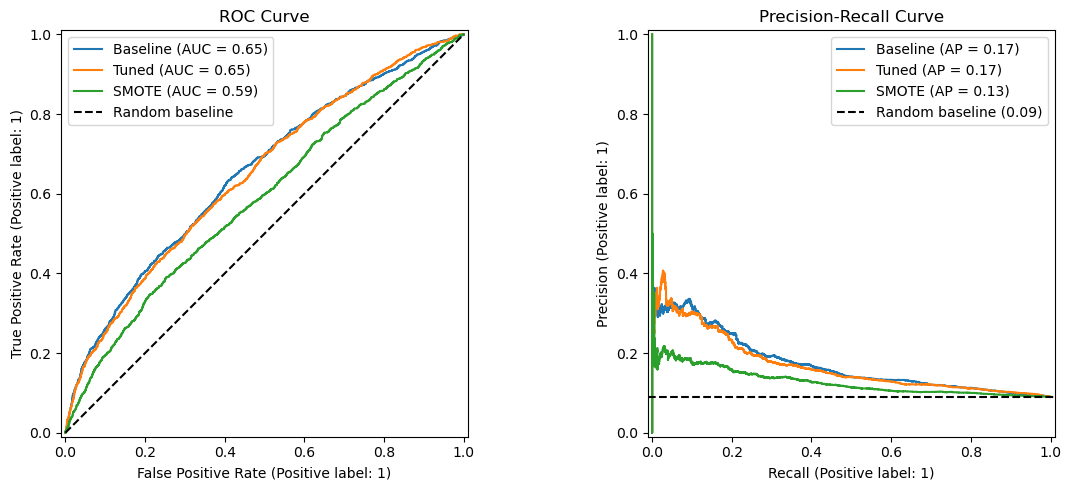

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, base_pred_prob,  ax=axes[0], name='Baseline')
RocCurveDisplay.from_predictions(y_test, y_pred_prob,     ax=axes[0], name='Tuned')
RocCurveDisplay.from_predictions(y_test, smote_pred_prob, ax=axes[0], name='SMOTE')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random baseline')
axes[0].set_title('ROC Curve')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, base_pred_prob,  ax=axes[1], name='Baseline')
PrecisionRecallDisplay.from_predictions(y_test, y_pred_prob,     ax=axes[1], name='Tuned')
PrecisionRecallDisplay.from_predictions(y_test, smote_pred_prob, ax=axes[1], name='SMOTE')
baseline_rate = y_test.mean()
axes[1].axhline(baseline_rate, color='k', linestyle='--', label=f'Random baseline ({baseline_rate:.2f})')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('../Results/LR_Results/roc_pr_curves_lr.png', dpi=150)
plt.show()

The **ROC curves** show Baseline and Tuned performing similarly (~0.65 AUC), while SMOTE drops notably (~0.59) — barely better than random. The **Precision-Recall curve** makes this even clearer: SMOTE's curve barely rises above the random baseline (dashed at 0.09), while Tuned maintains better precision at equivalent recall levels. For logistic regression, class weighting outperforms resampling on this dataset.

## 8. Tuned Model Coefficients

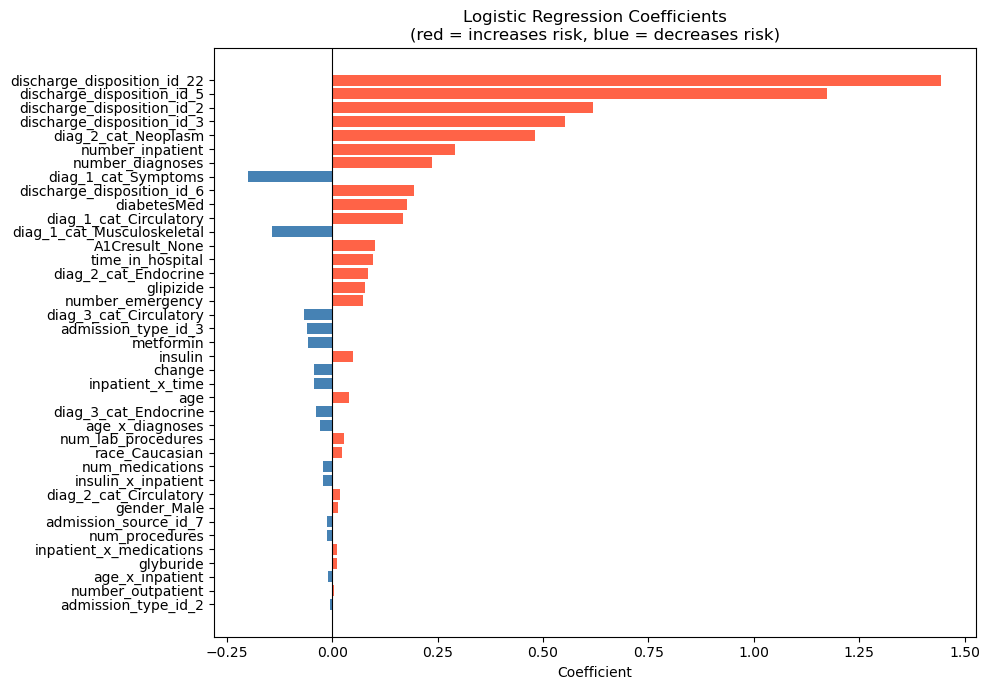

In [12]:
# Positive coefficient = increases readmission risk
# Negative coefficient = decreases readmission risk
feature_names = X_train_top.columns.tolist()

coef_df = (
    pd.DataFrame({'feature': feature_names, 'coefficient': model.coef_[0]})
    .reindex(pd.Series(model.coef_[0]).abs().sort_values(ascending=False).index)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'][::-1], coef_df['coefficient'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient')
ax.set_title('Logistic Regression Coefficients\n(red = increases risk, blue = decreases risk)')
plt.tight_layout()
plt.savefig('../Results/LR_Results/lr_coefficients.png', dpi=150)
plt.show()

Red bars increase readmission risk, blue bars decrease it. `discharge_disposition_id_22` (transfer to another inpatient facility) and `number_inpatient` are the strongest positive predictors — patients being transferred or repeatedly hospitalized are highest risk. Strong negative coefficients (blue) suggest certain discharge pathways are associated with safer outcomes. The interaction terms (e.g., `inpatient_x_medications`) also appear in the chart, confirming the combined effects added meaningful signal beyond the individual features.